# Movie Recommendation System
Enhanced filtering, TF-IDF, and Cosine Similarity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pickle
import os
import nltk
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
nltk.download('punkt_tab')
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\callp\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\callp\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 1. Load & Merge

In [2]:
movies = pd.read_csv('../data/tmdb_5000_movies.csv')
credits = pd.read_csv('../data/tmdb_5000_credits.csv')
df = movies.merge(credits, on='title')
print(f'Merged shape: {df.shape}')

Merged shape: (4809, 23)


## 2. EDA

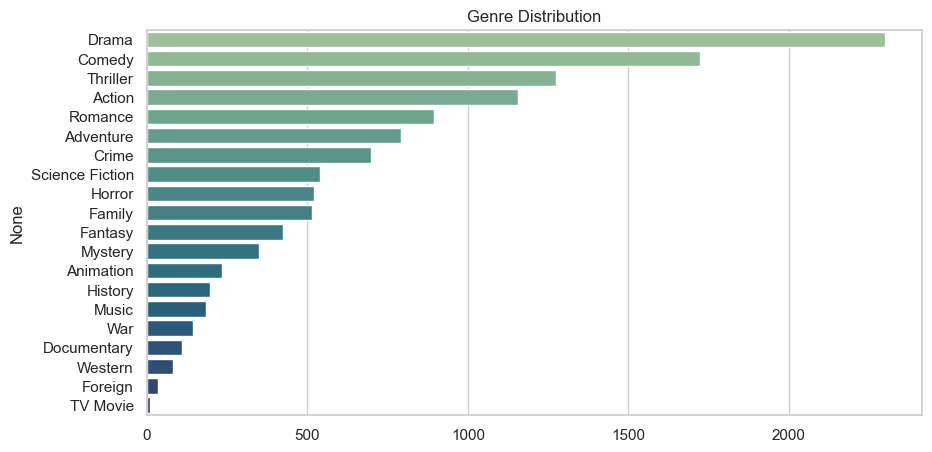

In [3]:
def extract_names(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

df['parsed_genres'] = df['genres'].apply(extract_names)
all_genres = [g for sub in df['parsed_genres'] for g in sub]
genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='crest', legend=False)
plt.title('Genre Distribution')
plt.show()

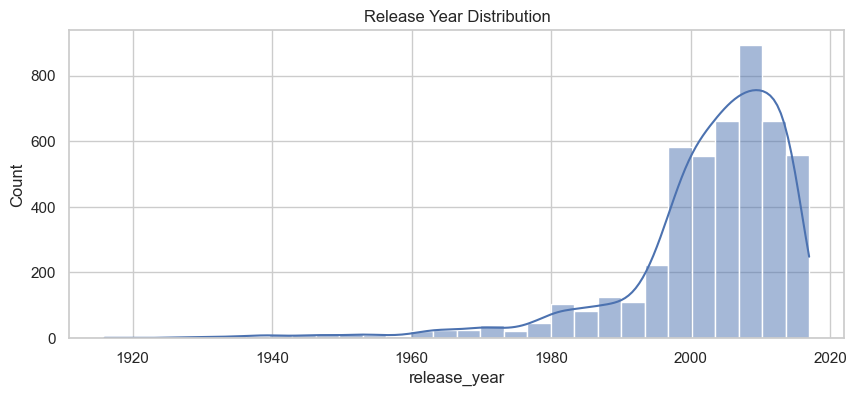

In [4]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
plt.figure(figsize=(10, 4))
sns.histplot(df['release_year'].dropna(), bins=30, kde=True)
plt.title('Release Year Distribution')
plt.show()

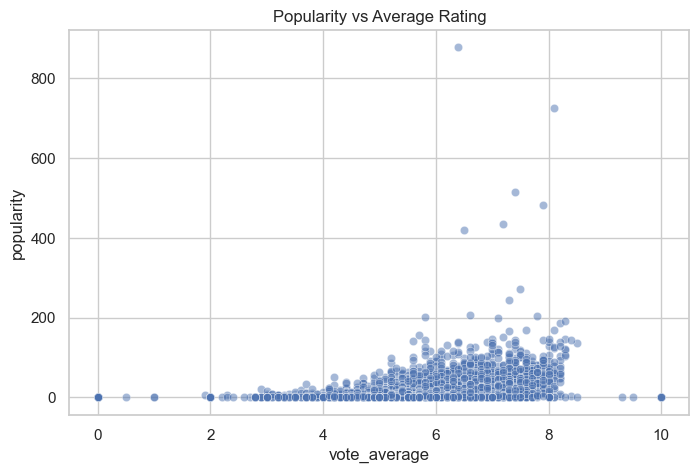

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='vote_average', y='popularity', alpha=0.5)
plt.title('Popularity vs Average Rating')
plt.show()

## 3. Feature Engineering

In [6]:
movies_df = df[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew', 'release_date', 'vote_average', 'popularity', 'original_language']].copy()
movies_df.dropna(subset=['overview', 'release_date'], inplace=True)
movies_df.reset_index(drop=True, inplace=True)

def convert_cast(obj):
    return [i['name'] for i in ast.literal_eval(obj)][:5]

def fetch_director(obj):
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            return [i['name']]
    return []

movies_df['genres'] = movies_df['genres'].apply(extract_names)
movies_df['keywords'] = movies_df['keywords'].apply(extract_names)
movies_df['cast'] = movies_df['cast'].apply(convert_cast)
movies_df['crew'] = movies_df['crew'].apply(fetch_director)

industry_map = {'en':'Hollywood', 'hi':'Bollywood', 'fr':'French Cinema', 'ko':'Korean Cinema', 'ja':'Japanese Cinema', 'zh':'Chinese Cinema', 'cn':'Chinese Cinema', 'es':'Spanish Cinema', 'de':'German Cinema', 'it':'Italian Cinema', 'ru':'Russian Cinema'}
movies_df['industry'] = movies_df['original_language'].map(lambda x: industry_map.get(x, 'Other'))

def get_rating_tier(v):
    if v <= 4: return 'Low'
    elif v <= 6: return 'Average'
    elif v <= 7: return 'Good'
    elif v <= 8: return 'Very Good'
    else: return 'Excellent'

movies_df['rating_tier'] = movies_df['vote_average'].apply(get_rating_tier)

## 4. Build Tag Column

In [7]:
def collapse(L):
    return [i.replace(' ', '') for i in L]

movies_df['tags'] = movies_df['overview'].apply(lambda x: x.split()) + \
                    movies_df['genres'].apply(collapse) + \
                    movies_df['keywords'].apply(collapse) + \
                    movies_df['cast'].apply(collapse) + \
                    movies_df['crew'].apply(collapse) + \
                    movies_df['industry'].apply(lambda x: [x.replace(' ', '')]) + \
                    movies_df['rating_tier'].apply(lambda x: [x.replace(' ', '')])

movies_df['tags'] = movies_df['tags'].apply(lambda x: ' '.join(x).lower())

ps = PorterStemmer()
def stem_text(text):
    return ' '.join([ps.stem(w) for w in text.split()])

movies_df['tags'] = movies_df['tags'].apply(stem_text)

## 5. TF-IDF Vectorization & Cosine Similarity

In [8]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors = tfidf.fit_transform(movies_df['tags']).toarray()
similarity = cosine_similarity(vectors)
print(f'Vectors shape: {vectors.shape}')
print(f'Similarity shape: {similarity.shape}')

Vectors shape: (4805, 5000)
Similarity shape: (4805, 4805)


## 6. Test Recommendations

In [9]:
def recommend(title):
    try:
        idx = movies_df[movies_df['title'].str.lower() == title.lower()].index[0]
    except IndexError:
        print('Movie not found.')
        return
    distances = similarity[idx]
    results = sorted(list(enumerate(distances)), key=lambda x: x[1], reverse=True)[1:9]
    print(f'Recommendations for {movies_df.iloc[idx].title}:')
    for i, dist in results:
        print(f'  {movies_df.iloc[i].title} ({dist:.3f})')

recommend('Avatar')
print()
recommend('The Dark Knight')

Recommendations for Avatar:
  Falcon Rising (0.222)
  Aliens (0.216)
  Battle: Los Angeles (0.200)
  Aliens vs Predator: Requiem (0.197)
  Apollo 18 (0.181)
  Star Trek Into Darkness (0.177)
  Meet Dave (0.167)
  Jarhead (0.157)

Recommendations for The Dark Knight:
  The Dark Knight Rises (0.457)
  Batman Returns (0.388)
  Batman Begins (0.365)
  Batman Forever (0.285)
  Batman: The Dark Knight Returns, Part 2 (0.279)
  Batman v Superman: Dawn of Justice (0.249)
  Batman & Robin (0.227)
  Batman (0.220)


## 7. Export Models

In [10]:
os.makedirs('../model', exist_ok=True)

movies_export = movies_df[['movie_id', 'title', 'release_date', 'vote_average', 'popularity', 'genres', 'industry', 'cast', 'rating_tier', 'original_language']].copy()
movies_export['director'] = movies_df['crew'].apply(lambda x: x[0] if len(x) > 0 else '')

with open('../model/movies_data.pkl', 'wb') as f:
    pickle.dump(movies_export, f)

num_movies = len(movies_df)
top_recs = np.zeros((num_movies, 12), dtype=np.int32)
for idx in range(num_movies):
    dists = similarity[idx]
    top = sorted(list(enumerate(dists)), key=lambda x: x[1], reverse=True)[1:13]
    top_recs[idx] = [t[0] for t in top]

with open('../model/similarity_indices.pkl', 'wb') as f:
    pickle.dump(top_recs, f)

all_actors = [a for sub in movies_export['cast'] for a in sub]
top_actors = [x[0] for x in pd.Series(all_actors).value_counts().head(500).items()]

filter_options = {
    'industries': sorted(movies_export['industry'].unique().tolist()),
    'genres': sorted(list(set([g for sub in movies_export['genres'] for g in sub]))),
    'actors': sorted(top_actors),
    'rating_tiers': ['Low', 'Average', 'Good', 'Very Good', 'Excellent']
}

with open('../model/filter_options.pkl', 'wb') as f:
    pickle.dump(filter_options, f)

print('Export complete!')
print(f'movies_data.pkl size: {os.path.getsize("../model/movies_data.pkl") / 1024:.2f} KB')
print(f'similarity_indices.pkl size: {os.path.getsize("../model/similarity_indices.pkl") / 1024:.2f} KB')
print(f'filter_options.pkl size: {os.path.getsize("../model/filter_options.pkl") / 1024:.2f} KB')

Export complete!
movies_data.pkl size: 919.34 KB
similarity_indices.pkl size: 225.39 KB
filter_options.pkl size: 8.29 KB
